In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../results/experiment_results.csv")

df.head()

,algorithm,matrix_size,pair_id,time_seconds,memory_before_kb,memory_after_kb,memory_difference_kb
0,iterative,64,1,0.000154,2432,2432,0
1,recursive,64,1,0.006554,2432,2432,0
2,hybrid,64,1,0.000147,2432,2432,0
3,iterative,64,2,0.000185,2432,2432,0
4,recursive,64,2,0.005920,2432,2432,0


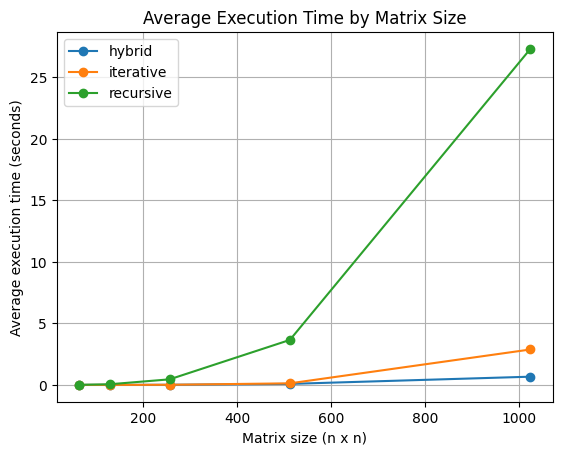

In [6]:
summary = (
    df.groupby(["algorithm", "matrix_size"])
      .agg(
          avg_time_seconds=("time_seconds", "mean"),
          avg_peak_memory_kb=("memory_after_kb", "mean"),
          avg_memory_increase_kb=("memory_difference_kb", "mean")
      )
      .reset_index()
)

summary

for algorithm in summary["algorithm"].unique():
    data = summary[summary["algorithm"] == algorithm]
    plt.plot(data["matrix_size"], data["avg_time_seconds"], marker="o", label=algorithm)

plt.xlabel("Matrix size (n x n)")
plt.ylabel("Average execution time (seconds)")
plt.title("Average Execution Time by Matrix Size")
plt.legend()
plt.grid(True)
plt.show()